# Course Overview

Peter Ralph  
2026-01-05

# Course Overview

*Data Mining, Exploration, and Visualization*

Peter Ralph

https://uodsci.github.io/ds435

## Steps in data analysis

1.  Care, or at least think, about the data.
2.  Look at the data.
3.  Query the data.
4.  Check the results.
5.  Communicate.

## In this class:

-   I just got this dataset. *What* is in it, actually?
-   Well, that’s messy. Let’s tidy it up.
-   Something sure went wrong with *those* values. Best to ignore them.
-   I’ve *still* just got a giant pile of *numbers*. How about some
    pictures?
-   My data are 52-dimensional, but I can only draw pictures in 2(ish)
    dimensions?
-   Uh-oh, these data aren’t even numbers, they’re words.
-   Uh-oh, these data aren’t even numbers, they’re images.

## 

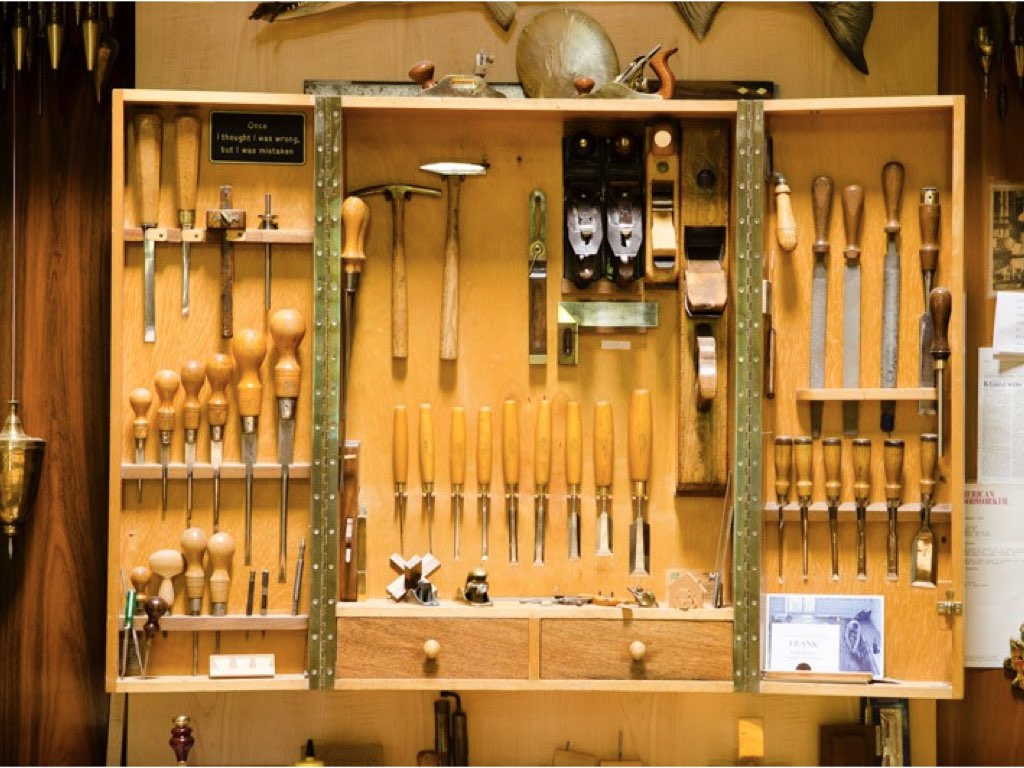  

*image: Frank Klausz, woodandshop.com*

## Exploratory data analysis

> It is important to understand what you CAN do before you learn to
> measure how WELL you seem to have DONE it. (*Tukey, Exploratory Data
> Analysis*)

This is particularly important now that the thing you’re doing might be
“throw everything into a neural network”.

## Exploratory data analysis

**Goals**:

-   To get a sense for what the data represent: how much data? what
    types of values? what are typical values? what does this imply about
    how the data were collected?
-   To understand the contours of the data: what range of values are
    represented, with what frequency? are there obvious relationships?
-   To identify potentially problematic aspects: errors? outliers?
    strong confounding?
-   To intuit how the data can be used to answer the question(s) at
    hand: where are the sources of information? what confounding
    relationships need to be considered?
-   To propose transformations or adjustments that might help.

For instance:

-   This was a survey of 200 third-graders at two different schools.
-   Most of the observations have some missing measurements.
-   Temperature changes seasonally.
-   Most activity happens between 6pm and 8pm.

## Tools already in your belt:

-   looking at the raw numbers in a text file (yes!!!)
-   tables of counts
-   means and medians and IQRs and so forth
-   histograms and boxplots and violinplots
-   scatterplots (all-pairwise! with colors!)
-   residuals from quick and simple linear models
-   doing PCA

Basically:

> First, look at the data.

# Structure of the course

Let’s have a look at the course webpage:
<https://uodsci.github.io/ds435>

## How to get the course material:

You probably want to have the content *locally*. Suggested workflow to
avoid merge conflicts:

1.  clone the git repository (at <https://github.com/uodsci/ds435>)
2.  find the slides in `docs/slides/`[1]
3.  do *not* open my `.ipynb` files!
4.  instead: copy them (e.g., to `introduction-mine.ipynb`) to a new
    file in the same directory, and open/edit *that* version
5.  update simply by doing `git pull`

This will give you a low-stakes chance to get used to git when
inevitably things get messed up.

# Exploring words: a preview

## Text analysis

In [data/passages.txt](data/passages.txt) we have a number of short
passages from a few different books. What distinguishes the passages?
The books?

The sources of the passages are in
[data/passage_sources.tsv](data/passage_sources.tsv).

What’s going to happen:
$$ \text{text} \rightarrow \text{big matrix} \rightarrow \text{data frame of features} $$
The second arrow is *ordination* or *dimension reduction*, via PCA.
We’ll be looking at lots of ways to do this.

## Turn the data into a matrix

[1] these are generated from the files in slides/, confusingly

In [ ]:
from collections import defaultdict

pfile = open("data/passages.txt", "r")
passages = pfile.read().split("\n")[:-1]
sources = pd.read_table("data/passage_sources.tsv")
words = np.unique(" ".join(passages).split(" "))[1:]
def tabwords(x, words):
    d = defaultdict(int)
    for w in x.split(" "):
        d[w] += 1
    out = np.array([d[w] for w in words])
    return out

wordmat = np.array([tabwords(x, words) for x in passages])

##

In [ ]:
passages[1]

##

In [ ]:
for w, x in zip(words[:20], wordmat[:20,:].T):
    print(f"{w}: {x}")

In [ ]:
wordmat.shape

## PCA

We will “do PCA” here by hand, by finding the singular value
decomposition (SVD) of the data matrix.

(And: note the standardization!)

In [ ]:
from scipy.sparse.linalg import svds
# center and scale the data
x = wordmat - np.mean(wordmat, axis=1)[:,np.newaxis]
x /= np.std(x, axis=1)[:, np.newaxis]
pcs, evals, evecs = svds(x, k=3)
eord = np.argsort(evals)[::-1]
evals = evals[eord]
evecs = evecs[eord,:]
pcs = pcs[:,eord]

## The loadings

In [ ]:
loadings = pd.DataFrame(evecs.T, columns=[f"PC{k}" for k in range(1,4)], index=words)
loadings

## The PCs

In [ ]:
pcdf = pd.concat([pd.DataFrame({"PC"+str(k+1) : pcs[:,k] for k in range(pcs.shape[1])}), sources], axis=1)
pcdf

##

In [ ]:
p1 = p9.ggplot(pcdf, p9.aes(x="PC1", y="PC2", color="source")) + p9.geom_point(size=3, show_legend=False)
p2 = p9.ggplot(pcdf, p9.aes(x="PC2", y="PC3", color="source")) + p9.geom_point(size=3)
p1 | p2

## PC 1 is length

In [ ]:
pcdf['lengths'] = np.sum(wordmat, axis=1)
p9.ggplot(pcdf, p9.aes(x="PC1", y="lengths", color="source")) + p9.geom_point(size=3) + p9.labs(x="PC1", y="passage length")

## PC2 is book

In [ ]:
loadings.sort_values("PC2").head(20)

##

In [ ]:
loadings.sort_values("PC2").tail(20)

## PC3?

In [ ]:
loadings.sort_values("PC3").head(20)

##

In [ ]:
loadings.sort_values("PC3").tail(20)

## This is also “PCA”:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import PCA
vectorizer = CountVectorizer(stop_words='english', min_df=5)
X = vectorizer.fit_transform(passages)
pca = PCA(n_components=3)
coords = pca.fit_transform(X.toarray())
pcdf2 = pd.concat([pd.DataFrame({"PC"+str(k+1) : coords[:,k] for k in range(coords.shape[1])}), sources], axis=1)
pcdf2

##